# Heart Disease Presence Prediction — Exploratory Data Analysis

> **For research and educational purposes only.** This notebook explores a historical
> public dataset. Nothing here is a medical diagnosis or medical advice.

This notebook is a thin view over the reusable `ml` package. Re-run
`python -m ml.eda.run heart` to regenerate `reports/heart/`.


In [1]:
import sys, os
# Make the repository root importable when the kernel starts in notebooks/.
_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)  # so relative paths (reports/, data/) resolve from the repo root

import pandas as pd
pd.set_option("display.max_columns", 60)

from ml.data.loaders import load_heart
from ml.eda import profile

X, y, spec = load_heart()
print(spec.notes)


Target: raw 'num' in {0..4} mapped to binary (num > 0 => 1). 'ca' and 'thal' contain missing values (originally '?'), imputed inside the model pipeline. 'ca' (vessel count) and 'slope' are ordinal but modelled as categorical. Cleveland single-site cohort, n=303.


## 1. Dataset overview

In [2]:
profile.dataset_overview(X, y, spec)

{'disease': 'heart',
 'n_rows': 303,
 'n_features': 13,
 'n_numeric': 5,
 'n_categorical': 5,
 'n_binary': 3,
 'target': 'heart_disease_present',
 'target_positive_meaning': "Target: raw 'num' in {0",
 'total_missing_cells': 6,
 'rows_with_any_missing': 6,
 'duplicate_rows': 0,
 'memory_mb': np.float64(0.032)}

## 2. Target distribution

In [3]:
display(profile.target_distribution(y))
print("class-imbalance ratio (majority / minority):", profile.class_imbalance_ratio(y))


,class,count,proportion
0,0,164,0.5413
1,1,139,0.4587


class-imbalance ratio (majority / minority): 1.18


## 3. Missing values

In [4]:
profile.missing_value_table(X)

,column,dtype,n_missing,pct_missing,n_unique
0,ca,float64,4,1.32,4
1,thal,float64,2,0.66,3
2,chol,int64,0,0.00,152
3,trestbps,int64,0,0.00,50
4,age,int64,0,0.00,41
5,oldpeak,float64,0,0.00,40
6,thalach,int64,0,0.00,91
7,restecg,int64,0,0.00,3
8,cp,int64,0,0.00,4
9,slope,int64,0,0.00,3


## 4. Numeric feature summary

In [5]:
profile.numeric_summary(X, spec)

,count,mean,std,min,25%,50%,75%,max,missing,skew
age,303.0,54.439,9.039,29.0,48.0,56.0,61.0,77.0,0,-0.209
trestbps,303.0,131.690,17.600,94.0,120.0,130.0,140.0,200.0,0,0.706
chol,303.0,246.693,51.777,126.0,211.0,241.0,275.0,564.0,0,1.136
thalach,303.0,149.607,22.875,71.0,133.5,153.0,166.0,202.0,0,-0.537
oldpeak,303.0,1.040,1.161,0.0,0.0,0.8,1.6,6.2,0,1.270


## 5. Outlier scan (IQR fences — diagnostic only, nothing removed)

In [6]:
profile.outlier_scan(X, spec)

,column,q1,q3,iqr_lower_fence,iqr_upper_fence,n_outliers,pct_outliers,min,max
0,age,48.0,61.0,28.50,80.50,0,0.00,29.0,77.0
1,trestbps,120.0,140.0,90.00,170.00,9,2.97,94.0,200.0
2,chol,211.0,275.0,115.00,371.00,5,1.65,126.0,564.0
3,thalach,133.5,166.0,84.75,214.75,1,0.33,71.0,202.0
4,oldpeak,0.0,1.6,-2.40,4.00,5,1.65,0.0,6.2


## 6. Numeric feature / target association (descriptive)

In [7]:
profile.target_feature_association(X, y, spec)

,feature,corr_with_target
0,oldpeak,0.425
1,thalach,-0.417
2,age,0.223
3,trestbps,0.151
4,chol,0.085


## 7. Categorical / binary breakdown

In [8]:
cs = profile.categorical_summary(X, spec)
for name, table in cs.items():
    print(f"--- {name} ---")
    display(table)


--- cp ---


,value,count,proportion
0,4,144,0.4752
1,3,86,0.2838
2,2,50,0.1650
3,1,23,0.0759


--- restecg ---


,value,count,proportion
0,0,151,0.4983
1,2,148,0.4884
2,1,4,0.0132


--- slope ---


...

,value,count,proportion
0,1,206,0.6799
1,0,97,0.3201


--- fbs ---


,value,count,proportion
0,0,258,0.8515
1,1,45,0.1485


--- exang ---


,value,count,proportion
0,0,204,0.6733
1,1,99,0.3267


## 8. Figures

Generated into `reports/heart/figures/`.

categorical_positive_rate.png


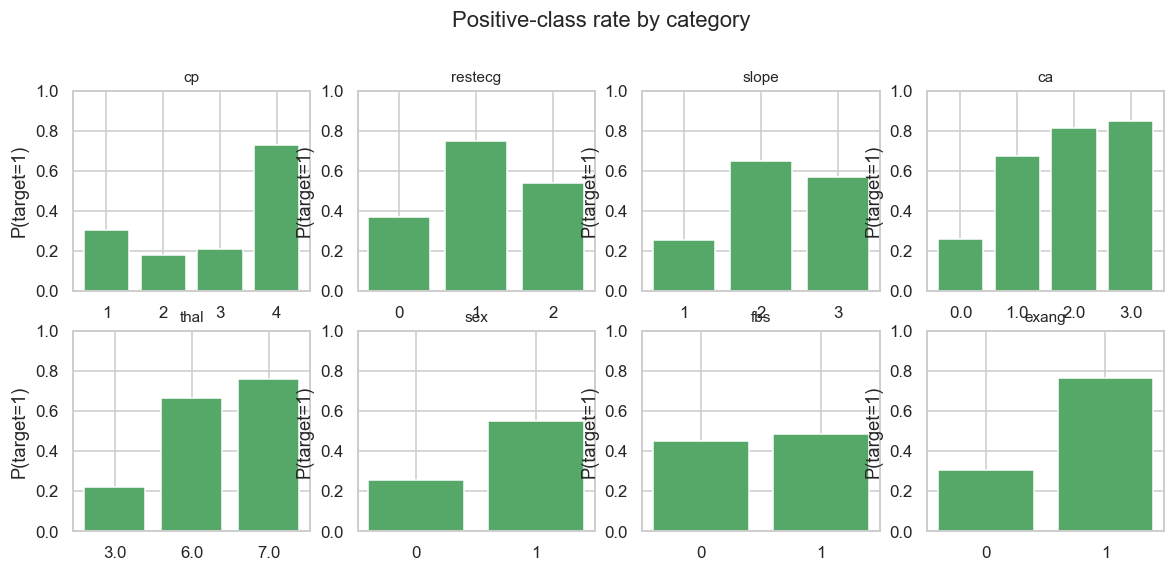

correlation_heatmap.png


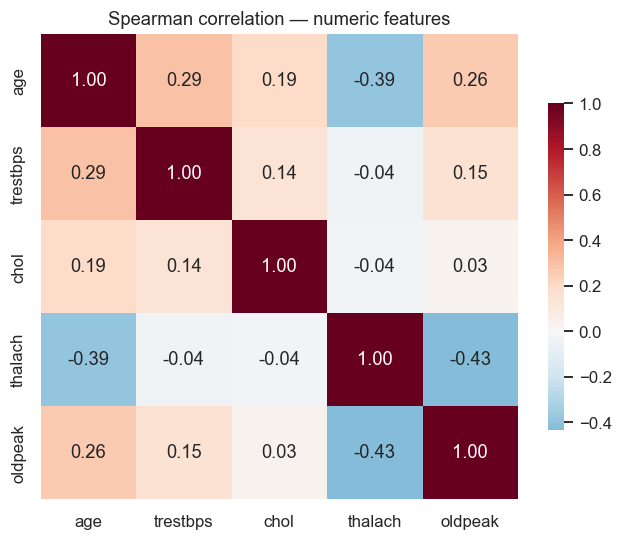

missingness.png


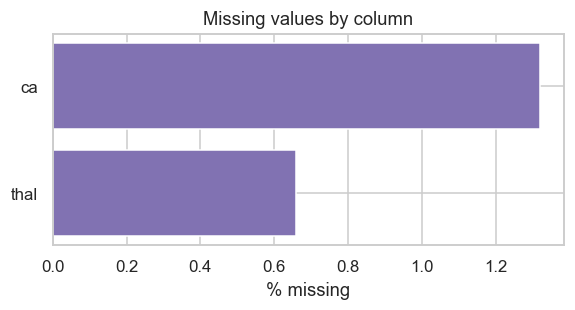

numeric_boxplots_by_target.png


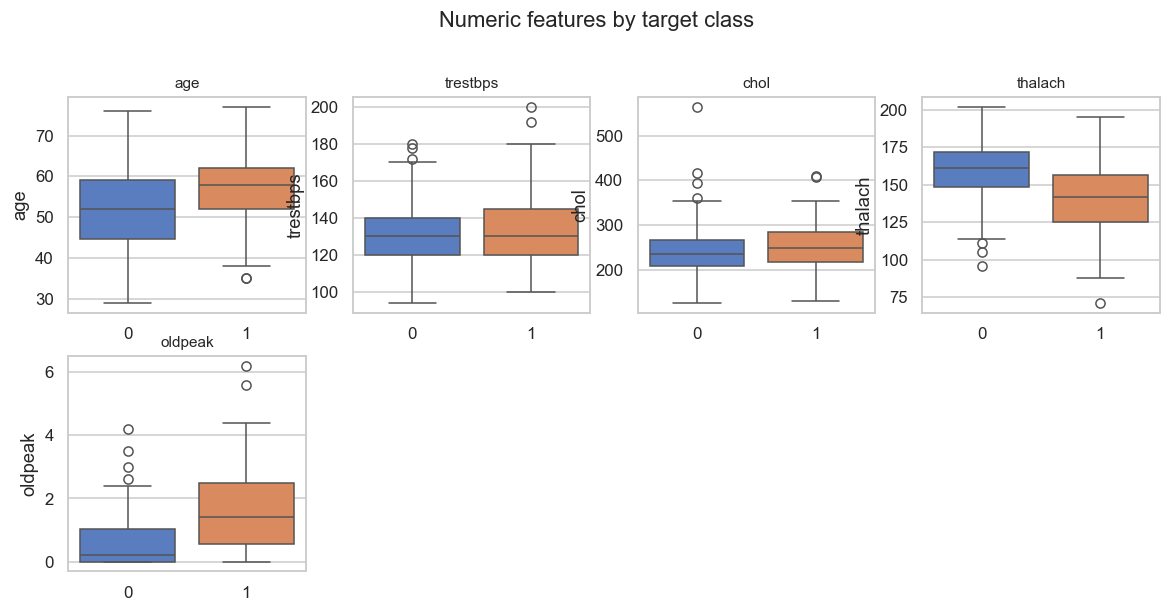

numeric_histograms.png


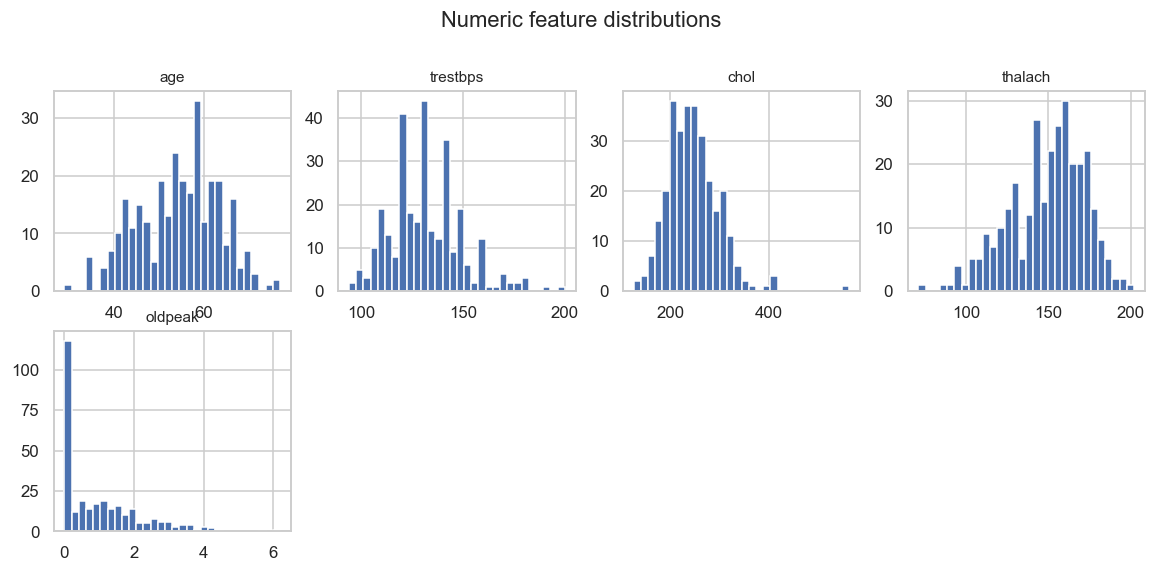

target_distribution.png


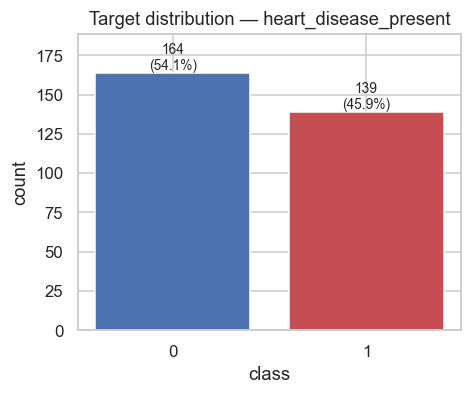

In [9]:
from pathlib import Path
from IPython.display import Image, display
from ml.eda.run import run_eda

run_eda("heart")
fig_dir = Path("reports") / "heart" / "figures"
for png in sorted(fig_dir.glob("*.png")):
    print(png.name)
    display(Image(filename=str(png)))


## 9. Written summaries

- Target definition + feature dictionary: [`reports/heart/TARGET.md`](../reports/heart/TARGET.md)
- EDA summary: [`reports/heart/EDA.md`](../reports/heart/EDA.md)
